In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
df = pd.read_csv('../data/cars_data.csv')

df.head()

,Car Name,Kilometers,Fuel,Transmission,Registration,EMI,Final Price,Location
0,2019 Maruti Swift,58358,CNG,Manual,DL-11,"EMI ₹8,120/m*",Account,"Gaur City mall, Multilevel parking, Greater N..."
1,2015 Hyundai Eon,43518,Petrol,Manual,DL-13,₹5.33L₹4.60 lakh+ other charges,₹4.05 lakh,"Metro Walk, Rohini, New Delhi"
2,2015 Maruti Wagon R 1.0,65974,CNG,Manual,DL-12,"EMI ₹7,918/m*",₹1.77 lakh,"Piyush Mahendra Mall, opp. Dussehra Ground, N..."
3,2015 Honda Amaze,40807,Petrol,Manual,DL-14,₹4.40L₹4.05 lakh+ other charges,₹2.13 lakh,"GNB Mall, Raj Nagar Extension, Ghaziabad"
4,2019 Maruti Swift,57241,Petrol,Manual,DL-12,"EMI ₹8,826/m*",₹2.35 lakh,"Radisson Blu, Sector 13, Dwarka, New Delhi"


In [ ]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset: (773, 8)

Columns:
Index(['Car Name', 'Kilometers', 'Fuel', 'Transmission', 'Registration', 'EMI',
       'Final Price', 'Location'],
      dtype='object')

Data Types:
Car Name        object
Kilometers       int64
Fuel            object
Transmission    object
Registration    object
EMI             object
Final Price     object
Location        object
dtype: object

Missing Values:
Car Name        0
Kilometers      0
Fuel            0
Transmission    0
Registration    0
EMI             0
Final Price     0
Location        0
dtype: int64

Statistical Summary:
          Kilometers
count     773.000000
mean    81941.882277
std     44830.301918
min      3910.000000
25%     52530.000000
50%     70254.000000
75%    100474.000000
max    301653.000000


In [ ]:
df['Final Price'] = df['Final Price'].replace('[₹,]', '', regex=True)
df['Final Price'] = pd.to_numeric(df['Final Price'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car Name      773 non-null    object 
 1   Kilometers    773 non-null    int64  
 2   Fuel          773 non-null    object 
 3   Transmission  773 non-null    object 
 4   Registration  773 non-null    object 
 5   EMI           773 non-null    object 
 6   Final Price   0 non-null      float64
 7   Location      773 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 48.4+ KB


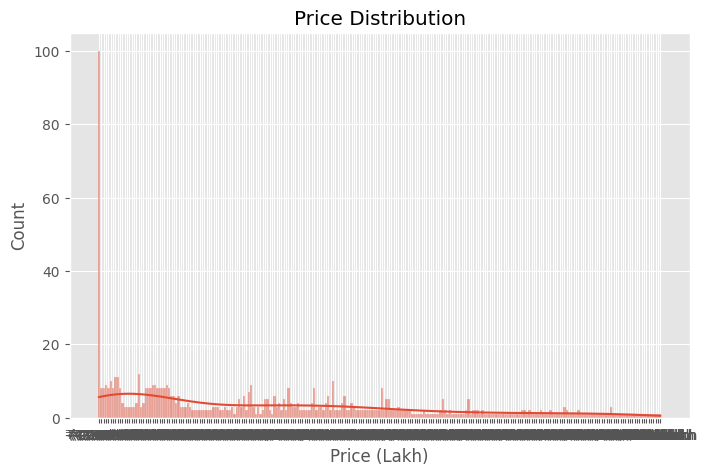

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Final Price'].dropna(),
    bins=20,
    kde=True
)

plt.title("Price Distribution")
plt.xlabel("Price (Lakh)")
plt.show()

In [ ]:
df['Final Price'] = (
    df['Final Price']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(' lakh', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['Final Price'] = pd.to_numeric(df['Final Price'], errors='coerce')

print(df['Final Price'].head())
print(df['Final Price'].dtype)

0     NaN
1    4.05
2    1.77
3    2.13
4    2.35
Name: Final Price, dtype: float64
float64


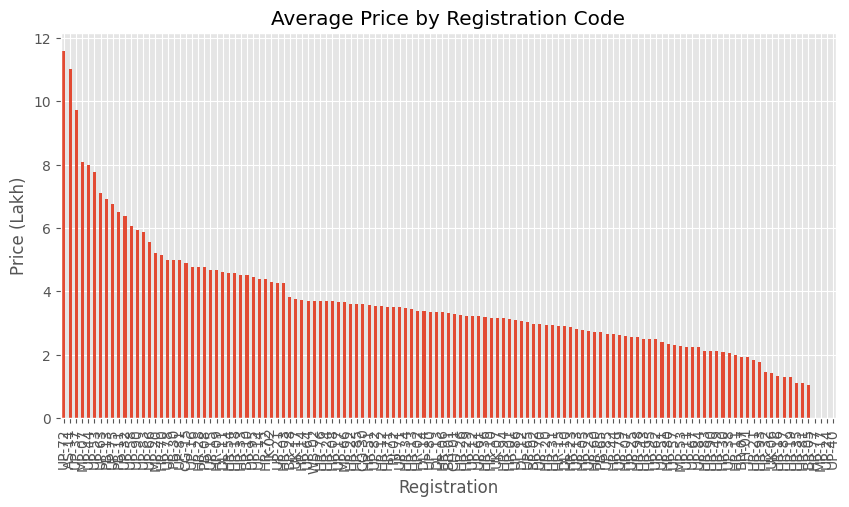

In [ ]:
reg_price = (
    df.groupby('Registration')['Final Price']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

reg_price.plot(kind='bar')

plt.title("Average Price by Registration Code")
plt.ylabel("Price (Lakh)")
plt.show()

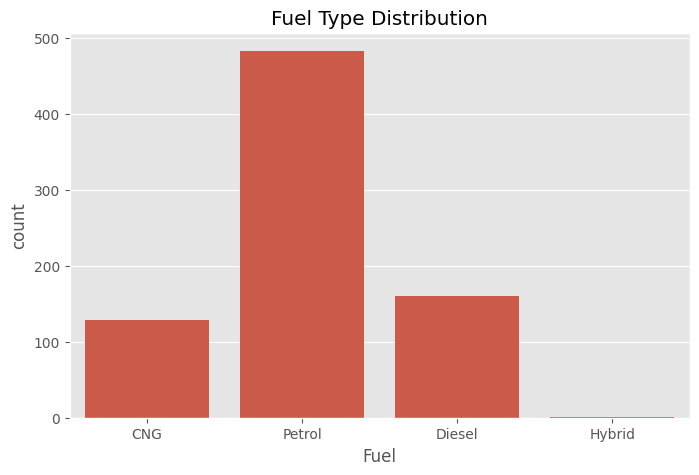

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Fuel',
    data=df
)

plt.title("Fuel Type Distribution")
plt.show()

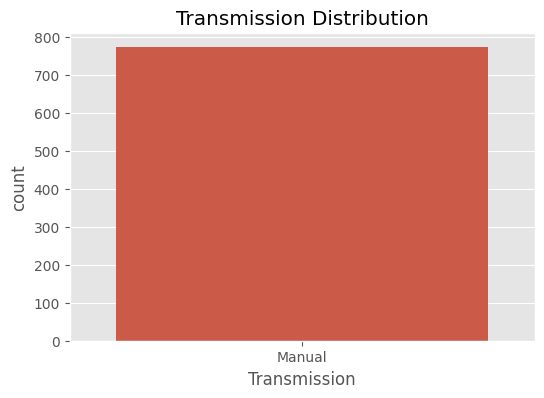

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Transmission', data=df)
plt.title("Transmission Distribution")
plt.show()

In [ ]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df[['Registration', 'Final Price']].isnull().sum())

print("\nFirst 5 rows:")
print(df[['Registration', 'Final Price']].head())

print("\nUnique Price Values:")
print(df['Final Price'].dropna().head(10))

Shape: (773, 8)

Missing Values:
Registration      0
Final Price     100
dtype: int64

First 5 rows:
  Registration  Final Price
0        DL-11          NaN
1        DL-13         4.05
2        DL-12         1.77
3        DL-14         2.13
4        DL-12         2.35

Unique Price Values:
1     4.05
2     1.77
3     2.13
4     2.35
5     3.65
6     2.48
7     1.79
8     3.75
9     3.09
10    2.75
Name: Final Price, dtype: float64


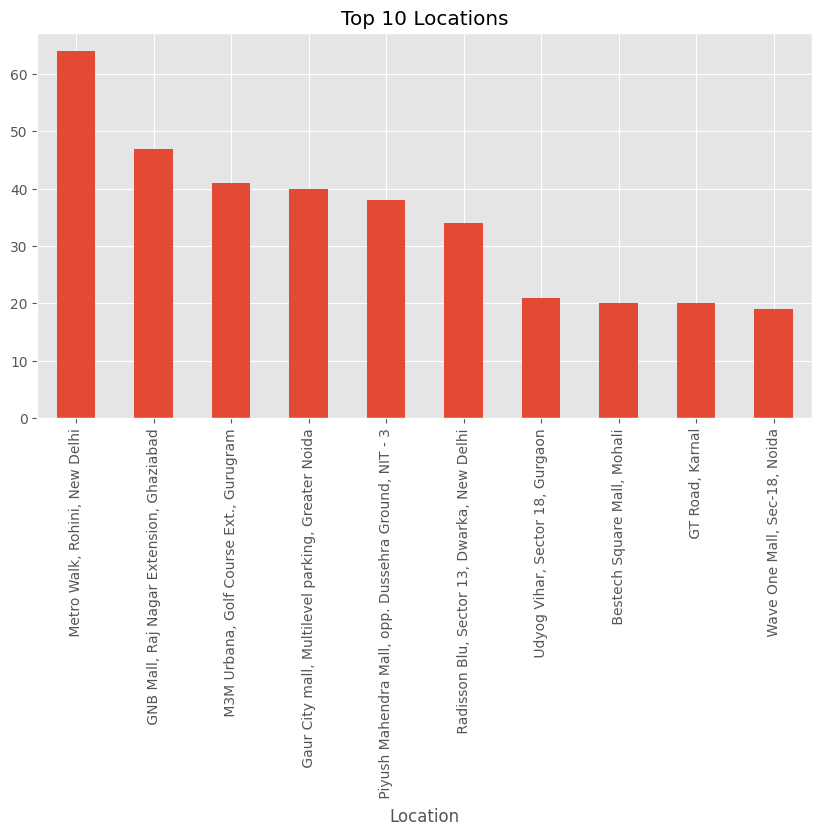

In [ ]:
plt.figure(figsize=(10,5))

df['Location'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Locations")
plt.show()

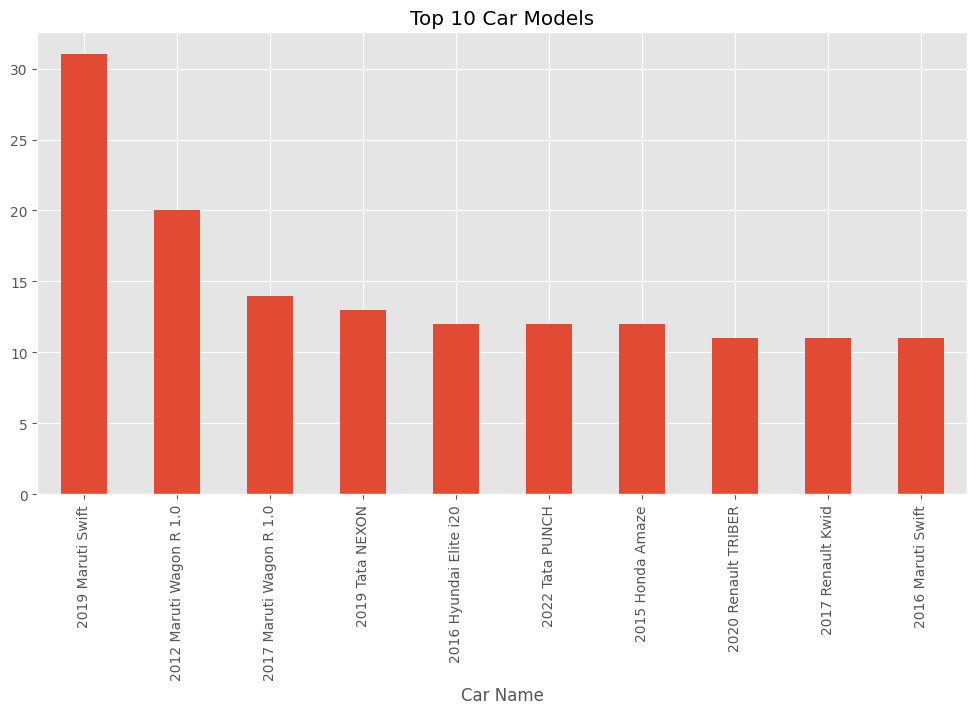

In [ ]:
plt.figure(figsize=(12,6))

df['Car Name'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Car Models")
plt.show()

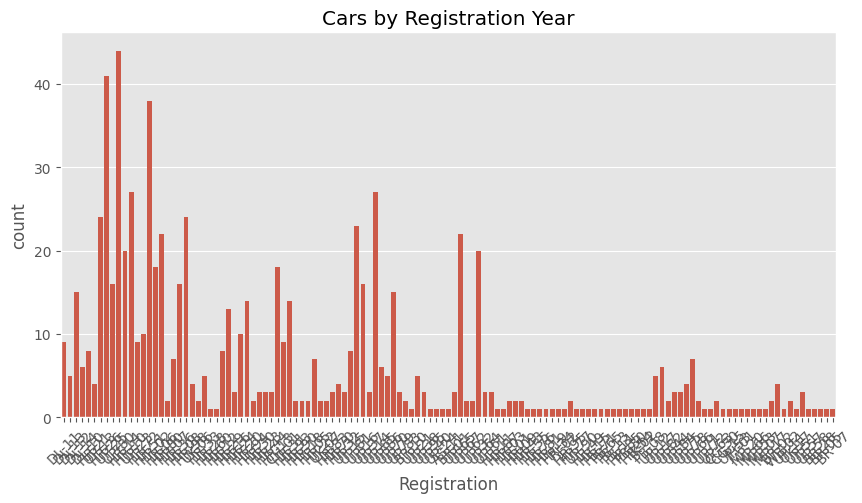

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Registration', data=df)
plt.xticks(rotation=45)
plt.title("Cars by Registration Year")
plt.show()

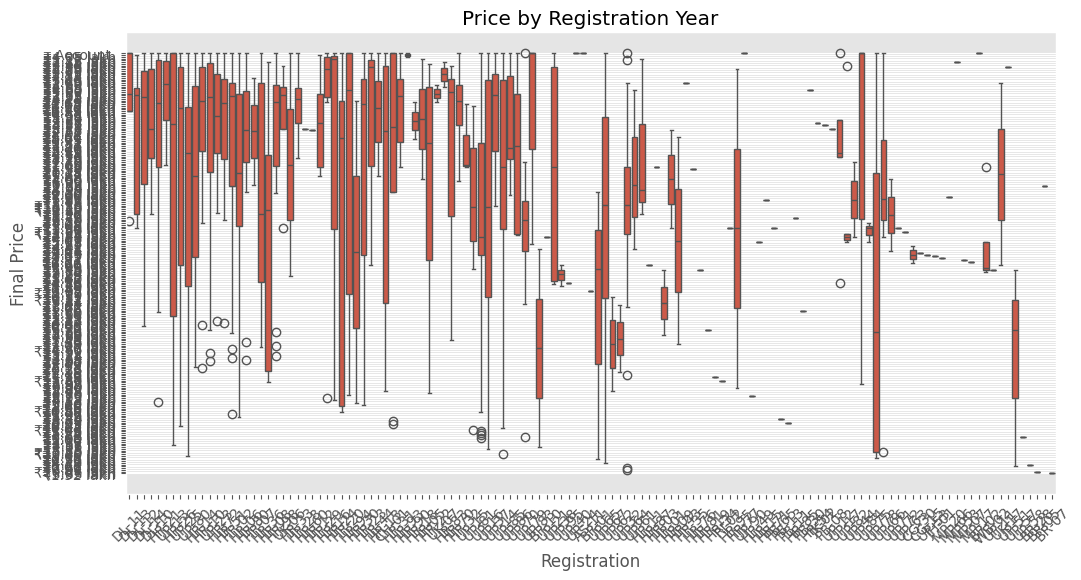

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Registration',
    y='Final Price',
    data=df
)

plt.xticks(rotation=45)
plt.title("Price by Registration Year")
plt.show()

Business Insights
1. Petrol Cars Dominate the Market
Petrol vehicles constitute the majority of listings.
Indicates higher demand and availability compared to other fuel types.
Buyers prefer petrol vehicles due to lower maintenance costs and better availability.
2. Used Car Market is Budget-Oriented
Most vehicles are priced between ₹1 lakh and ₹5 lakh.
Shows that the platform primarily caters to budget-conscious buyers.
Affordable cars have higher market turnover.
3. Certain Car Models Appear Frequently
Models from brands like Maruti, Hyundai, Tata, and Honda occur repeatedly.
These brands have strong resale value and customer trust.
Popular models drive a significant portion of listings.
4. Fuel Type Influences Vehicle Price
Diesel and premium fuel vehicles generally command higher prices.
Petrol vehicles offer a wider range of affordable options.
Fuel type is an important factor affecting resale value.
5. Location Impacts Inventory Availability
Some locations contribute a higher number of listings.
Urban regions tend to have greater inventory and variety.
Regional demand affects pricing and availability.
6. Registration Categories Show Market Concentration
Certain registration codes (e.g., DL-11, DL-12, DL-13) appear more frequently.
Indicates concentration of listings in specific regions.
Useful for targeted marketing and inventory planning.
7. High Mileage May Reduce Resale Value
Vehicles with higher kilometers driven generally have lower market prices.
Buyers place a premium on lower-usage vehicles.
Mileage is a key factor in used-car valuation.